#**PROYECTO INTELIGENCIA ARTIFICIAL: Detección temprana de cáncer de piel**
####Integrantes:
* Juan Carlos Elizalde Padilla - 2230028
* Juan David Gomez Mosquera - 2230062
* Erick Fabian Rodriguez Marin - 2221914

###**Problema y datos**
El HAM10000 (Human Against Machine with 10000 training images) es un dataset multimodal de dermatología que combina imágenes médicas reales con datos clínicos tabulares. Contiene 10,015 imágenes dermatoscópicas de lesiones de piel clasificadas en 7 tipos de cáncer y condiciones dermatológicas, recolectadas de hospitales en Austria y Australia durante más de 20 años. Es un dataset de referencia académica mundial, publicado en la revista Scientific Data de Nature.
TIPO DE FORMATO: Imágenes JPG + múltiples archivos CSV NÚMERO DE REGISTROS: 10,015 imágenes / filas en metadata NÚMERO DE VARIABLES: 7 columnas clínicas en metadata + versiones tabulares de imágenes en píxeles. TARGET: dx - tipo de lesión (Benigna - Maliciosa.) TIPOS DE VARIABLES: Numéricas (edad), categóricas (sexo, localización corporal, tipo de diagnóstico, tipo de lesión) e imagen convertida a píxeles en CSV.

El desafío es clasificar correctamente el tipo de diagnóstico según si es benigno o maligno por medio de imágenes.

Dasaset recuperado de: [Kaggle](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?select=HAM10000_metadata.csv)


###**Justificación de la IA**
Dada la gran variabilidad visual y el desequilibrio de datos en la clasificación de lesiones cutáneas, un modelo de Inteligencia Artificial supervisada puede identificar complejos patrones en imágenes médicas con mayor exactitud, lo que puede ayudar en la diferenciación entre lesiones cutáneas benignas y malignas [(Esteva et al., 2017)](https://www.nature.com/articles/nature21056). En cuanto a su aplicación, dado que se conoce que la detección temprana de cáncer de piel mejora decisiones clínica y aumenta las posibilidades de un tratamiento exitoso, se puede concluir que el modelo es apropiado para el problema [(Skin Cancer Classification With Deep Learning: A Systematic Review)](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9327733/).

https://chat.deepseek.com/share/fqs35be13zjdpcd9dt

---
#**1. Conjunto de datos**
---

Importación de librerías:

In [ ]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import seaborn as sns
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (confusion_matrix, make_scorer, recall_score,
                             precision_score, f1_score, balanced_accuracy_score,
                             roc_auc_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

Carga dataset:

In [ ]:
def cargar_csv(file_id):
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    return pd.read_csv(StringIO(requests.get(url).text))

meta     = cargar_csv("1HAcuf87ADCTFmT048xkx9LImkwnPjWwR")
ham8_l   = cargar_csv("1STRxSq4TZfNoS3SWKVtHzn4swVRx2wCU")
ham8_rgb = cargar_csv("1xfd7LOevJ-ueN4EufCK9tezH5tOq_sGI")
ham28_l  = cargar_csv("1BaP97p2QPDSgqwtB-FAXazXHjzGQ6yLv")
ham28_rgb= cargar_csv("1c9OPTuKl8k3xAVHMSfQV5-SvsoGGXoT6")

for nombre, df in [("meta", meta), ("ham8_l", ham8_l), ("ham8_rgb", ham8_rgb), ("ham28_l", ham28_l), ("ham28_rgb", ham28_rgb)]:
    print(f"{nombre}: {df.shape}")


meta: (10015, 7)
ham8_l: (10015, 65)
ham8_rgb: (10015, 193)
ham28_l: (10015, 785)
ham28_rgb: (10015, 2353)


Creación de la variable objetivo

In [ ]:
# El target es identificar mediante una fotografia si la lesion es benigna o maligna,
# para ello necesitamos crear una columna de target en el dataset de meta donde se
# especifique si lo es o no.
malignos = ['mel', 'bcc', 'akiec']
meta['target'] = meta['dx'].isin(malignos).astype(int)

En este método se analiza la intensidad global de la imagen, es decir, qué tan clara u oscura es la lesión en términos generales. Primero, si la imagen está en formato RGB, se convierte a escala de grises promediando los tres canales de color, lo que permite trabajar con una sola matriz de intensidades. A partir de esta representación, se calculan estadísticas básicas: la media (brillo promedio), la desviación estándar (variabilidad o contraste), y los valores mínimo y máximo. Estas métricas resumen cómo se distribuyen los niveles de gris en la imagen y permiten capturar diferencias generales entre lesiones más uniformes y otras más irregulares.


In [ ]:
#Intensidad global
import numpy as np

def features_intensidad(img):
    # img: array (H, W, 3) o (H, W)
    if len(img.shape) == 3:
        img_gray = np.mean(img, axis=2)
    else:
        img_gray = img

    return {
        'mean_intensity': np.mean(img_gray),
        'std_intensity': np.std(img_gray),
        'min_intensity': np.min(img_gray),
        'max_intensity': np.max(img_gray)
    }

En este método se estudia el comportamiento del color en la imagen, separando explícitamente los tres canales: rojo, verde y azul (RGB). Para cada canal se calcula la media, que representa la intensidad promedio de ese color en la lesión, y la desviación estándar, que indica qué tan variable es ese color dentro de la imagen. Esto permite identificar patrones donde ciertas lesiones presentan dominancia de un color o mayor variabilidad cromática. Dado que el dataset está en formato RGB intercalado, este paso reorganiza los datos correctamente para analizarlos por canal.

In [ ]:
#color
def features_color(img):
    # img RGB
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

    return {
        'r_mean': np.mean(r),
        'g_mean': np.mean(g),
        'b_mean': np.mean(b),
        'r_std': np.std(r),
        'g_std': np.std(g),
        'b_std': np.std(b)
    }

En este método se mide la asimetría de la lesión, una característica clínicamente relevante. Primero, la imagen se convierte a escala de grises para simplificar el análisis y luego se aplica un umbral automático (Otsu) para separar la lesión del fondo, generando una imagen binaria. Posteriormente, la imagen se divide en dos mitades verticales: izquierda y derecha. Una de las mitades se invierte horizontalmente para poder compararlas directamente. Finalmente, se calcula la diferencia absoluta entre ambas mitades y se normaliza respecto al tamaño de la imagen. Este valor cuantifica qué tan diferente es una mitad respecto a la otra, indicando el nivel de asimetría.

In [ ]:
#asimetria

import cv2

def features_asimetria(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # umbral simple
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

    # dividir imagen
    h, w = thresh.shape
    left = thresh[:, :w//2]
    right = np.fliplr(thresh[:, w//2:])

    # diferencia
    diff = np.sum(np.abs(left - right)) / (h * w)

    return {'asymmetry': diff}


En este método se analizan las propiedades geométricas de la lesión. Primero, se convierte la imagen a escala de grises y se aplica un umbral para obtener una versión binaria. Luego se detectan los contornos presentes en la imagen y se selecciona el más grande, asumiendo que corresponde a la lesión principal. A partir de este contorno se calculan tres métricas: el área (cantidad de píxeles dentro del contorno), el perímetro (longitud del borde), y la circularidad, que se obtiene mediante la fórmula 4π⋅area/perimetro^2
. Esta última mide qué tan cercana es la forma a un círculo perfecto, siendo útil para detectar bordes irregulares.

In [ ]:
#forma

def features_forma(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return {'area':0, 'perimeter':0, 'circularity':0}

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    circularity = (4 * np.pi * area) / (perimeter**2 + 1e-6)

    return {
        'area': area,
        'perimeter': perimeter,
        'circularity': circularity
    }


En este método se estudia la textura de la imagen, es decir, cómo se distribuyen espacialmente los niveles de intensidad. Primero se convierte la imagen a escala de grises. Luego se construye la matriz GLCM (Gray Level Co-occurrence Matrix), que registra con qué frecuencia aparecen pares de píxeles con determinados valores de intensidad en una relación espacial específica. A partir de esta matriz se calculan tres propiedades: el contraste (variación local de intensidades), la homogeneidad (similitud entre píxeles vecinos) y la energía (uniformidad de la textura). Estas métricas permiten capturar patrones finos que no son visibles solo con estadísticas globales.

In [ ]:
#textura
from skimage.feature import graycomatrix, graycoprops

def features_textura(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')[0,0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
    energy = graycoprops(glcm, 'energy')[0,0]

    return {
        'texture_contrast': contrast,
        'texture_homogeneity': homogeneity,
        'texture_energy': energy
    }

In [ ]:
#features

def extraer_features(img):
    f = {}

    f.update(features_intensidad(img))
    f.update(features_color(img))
    f.update(features_asimetria(img))
    f.update(features_forma(img))
    f.update(features_textura(img))

    return f


In [ ]:

def row_to_img_auto(row):
    arr = row.values.astype(float)

    # eliminar posibles columnas extra (para que sea divisible por 3)
    arr = arr[:len(arr) - (len(arr) % 3)]

    # calcular tamaño automáticamente
    size = int(np.sqrt(len(arr) / 3))

    return arr.reshape(size, size, 3).astype(np.uint8)


features_list = []

for i in range(len(ham28_rgb)):
    img = row_to_img_auto(ham28_rgb.iloc[i])
    feats = extraer_features(img)
    features_list.append(feats)

features_df = pd.DataFrame(features_list)

print("Features extraídas:", features_df.shape)
features_df.head(30)

Features extraídas: (10015, 17)


,mean_intensity,std_intensity,min_intensity,max_intensity,r_mean,g_mean,b_mean,r_std,g_std,b_std,asymmetry,area,perimeter,circularity,texture_contrast,texture_homogeneity,texture_energy
0,184.398384,18.366903,98.666667,222.333333,208.760204,162.755102,181.679847,11.214565,18.958500,27.091837,41.660714,577.0,134.568542,0.400404,171.010582,0.121686,0.036442
1,177.079082,34.473362,20.000000,227.666667,197.269133,156.664541,177.303571,35.645652,33.292243,36.776936,2.940051,663.0,99.455844,0.842292,286.541005,0.103578,0.031774
2,181.564201,15.659740,108.333333,220.666667,214.096939,156.468112,174.127551,12.996008,16.450575,20.431357,28.996173,457.5,105.154328,0.519932,114.183862,0.132186,0.036681
3,165.281037,32.687874,16.000000,226.000000,195.829082,142.706633,157.307398,36.911178,29.714297,33.358460,3.577806,670.5,99.213203,0.855992,219.402116,0.108413,0.033227
4,188.386054,39.408873,85.333333,253.333333,211.770408,168.068878,185.318878,32.804085,41.917258,45.345025,1.519133,301.0,154.083260,0.159318,421.121693,0.117195,0.029548
5,157.826531,66.551974,1.333333,252.000000,178.067602,140.938776,154.473214,68.236920,65.157531,67.798372,4.269133,565.5,100.526911,0.703198,931.884921,0.083899,0.028935
6,179.687075,9.098144,125.000000,195.000000,212.845663,162.878827,163.336735,7.118022,10.353416,11.687202,10.123724,616.0,135.740114,0.420121,25.775132,0.246526,0.058306
7,173.185374,21.419620,23.000000,201.333333,205.897959,159.403061,154.255102,22.245323,20.639169,22.199955,10.096939,502.5,94.183766,0.711859,77.247354,0.180244,0.040963
8,172.802296,23.100690,13.333333,212.666667,203.582908,149.252551,165.571429,23.022521,21.582187,25.831430,3.956633,585.0,105.740114,0.657486,105.994709,0.161259,0.040716
9,188.229592,19.762859,111.333333,224.000000,223.237245,163.827806,177.623724,15.176003,21.282950,24.743171,3.322704,686.0,111.798990,0.689697,120.359788,0.141785,0.038097


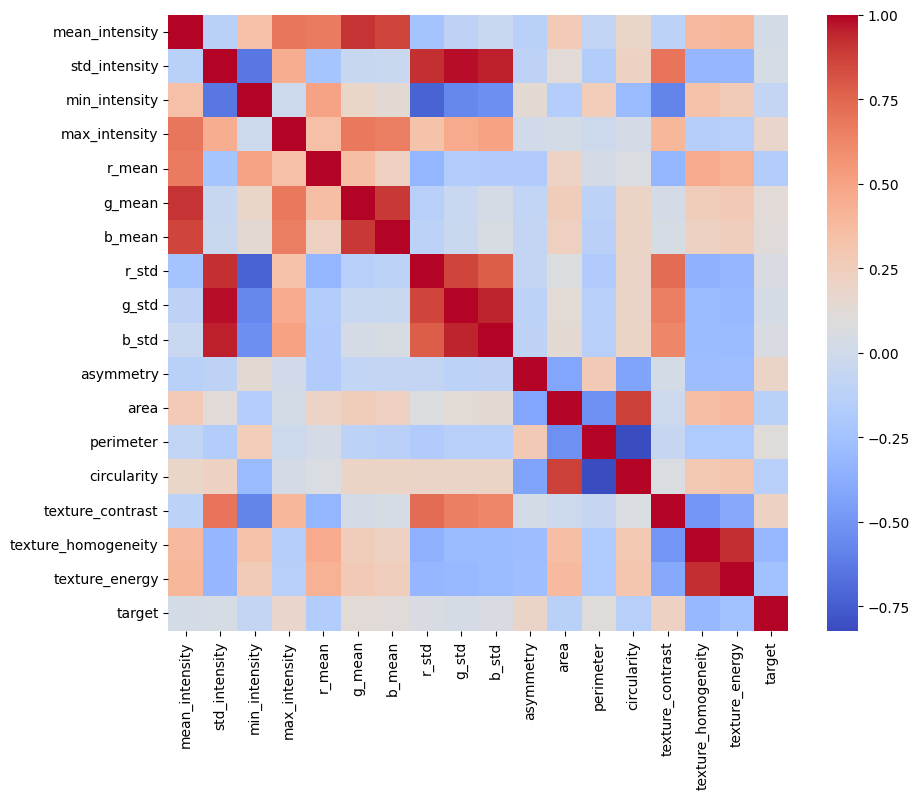

In [ ]:
df_final = pd.concat([features_df, meta['target']], axis=1)

corr = df_final.corr()
corr_target = corr.sort_values(by='target', ascending=False)['target']
corr_target

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [ ]:
corr_target = corr.sort_values(by='target', ascending=False)['target']
corr_target

,target
target,1.000000
texture_contrast,0.211098
asymmetry,0.195173
max_intensity,0.179063
g_mean,0.118416
b_mean,0.115324
perimeter,0.106574
r_std,0.057229
b_std,0.054616
std_intensity,0.045944


In [ ]:
df = features_df.copy()
df['target'] = meta['target']

# targets binarios separados
df['maligno'] = (df['target'] == 1).astype(int)
df['benigno'] = (df['target'] == 0).astype(int)

# conteo de clases
num_malignos = df['maligno'].sum()
num_benignos = df['benigno'].sum()

print(f"Cantidad de malignos: {num_malignos}")
print(f"Cantidad de benignos: {num_benignos}")

# correlaciones
corr_maligno = df.drop(columns=['target']).corr()['maligno'].drop('maligno').sort_values(ascending=False)
corr_benigno = df.drop(columns=['target']).corr()['benigno'].drop('benigno').sort_values(ascending=False)

print("\nCorrelación con MALIGNO:\n", corr_maligno)
print("\nCorrelación con BENIGNO:\n", corr_benigno)

Cantidad de malignos: 1954
Cantidad de benignos: 8061

Correlación con MALIGNO:
 texture_contrast       0.211098
asymmetry              0.195173
max_intensity          0.179063
g_mean                 0.118416
b_mean                 0.115324
perimeter              0.106574
r_std                  0.057229
b_std                  0.054616
std_intensity          0.045944
g_std                  0.035226
mean_intensity         0.018113
min_intensity         -0.068346
area                  -0.136900
circularity           -0.140716
r_mean                -0.173419
texture_energy        -0.258371
texture_homogeneity   -0.310971
benigno               -1.000000
Name: maligno, dtype: float64

Correlación con BENIGNO:
 texture_homogeneity    0.310971
texture_energy         0.258371
r_mean                 0.173419
circularity            0.140716
area                   0.136900
min_intensity          0.068346
mean_intensity        -0.018113
g_std                 -0.035226
std_intensity         -0.04594

Seleccion de features mas relevantes para el entrenamiento del modelo (Mayor correlacion)

In [ ]:
# Features con mayor correlación con maligno (en valor absoluto)
# Según las correlaciones, son:
# texture_contrast (0.211)
# asymmetry (0.195)
# max_intensity (0.179)
# texture_homogeneity (-0.311)
# area (-0.137)

# Lista de features a CONSERVAR (los que tienen |correlación| > 0.15 con maligno)
features_relevantes = [
    'texture_contrast',
    'asymmetry',
    'max_intensity',
    'texture_homogeneity',
    'area'
]

# Crear DataFrame solo con los features relevantes y el target, agregando age
df = features_df[features_relevantes].copy()
df['age'] = meta['age']
df['target'] = meta['target']

In [ ]:
df.head()

,texture_contrast,asymmetry,max_intensity,texture_homogeneity,area,age,target
0,171.010582,41.660714,222.333333,0.121686,577.0,80.0,0
1,286.541005,2.940051,227.666667,0.103578,663.0,80.0,0
2,114.183862,28.996173,220.666667,0.132186,457.5,80.0,0
3,219.402116,3.577806,226.000000,0.108413,670.5,80.0,0
4,421.121693,1.519133,253.333333,0.117195,301.0,75.0,0


Correjiremos los valores NaN presentes en la feature age, se reemplazara por la mediana, de esta manera serviran para el entrenamiento del modelo sin afectar en el rendimiento

In [ ]:
# Ver cuántos NaN hay en cada columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Opcional: ver las filas con NaN
print("\nFilas con NaN:")
print(df[df.isnull().any(axis=1)])

Valores nulos por columna:
texture_contrast        0
asymmetry               0
max_intensity           0
texture_homogeneity     0
area                    0
age                    57
target                  0
dtype: int64

Filas con NaN:
      texture_contrast  asymmetry  max_intensity  texture_homogeneity   area  \
968         136.902116  15.984694     220.666667             0.126537  709.0   
969         152.018519   3.281888     187.666667             0.118795  705.0   
970         185.843915   0.396684     194.000000             0.094703  729.0   
971         119.630952   9.112245     195.000000             0.184788  669.0   
972         176.314815   1.320153     207.666667             0.165531  727.0   
973          50.862434  11.711735     168.666667             0.226824  723.0   
974          75.683862  24.394133     186.666667             0.219163  729.0   
975         163.519841  14.988520     211.333333             0.113784  670.5   
977         175.067460   7.822704     191.

In [ ]:
# Calcular la mediana de 'age' (ignora automáticamente los NaN)
median_age = df['age'].median()

# Reemplazar los NaN de 'age' por la mediana calculada
df['age'] = df['age'].fillna(median_age)

# Verificar que no queden NaN
print("NaN restantes en age:", df['age'].isnull().sum())
print("Mediana usada:", median_age)

NaN restantes en age: 0
Mediana usada: 50.0


---
#**2. Separación de datos**
---

Metodo Split:

In [ ]:
# Separar features (X) y target (y)
X = df.drop('target', axis=1)
y = df['target']

# Dividir los datos en conjuntos de entrenamiento y prueba
# test_size=0.3: 70% entrenamiento, 30% prueba
# random_state=21: semilla para reproducibilidad
# stratify=y: mantiene la proporción de clases en ambos conjuntos (importante por el desbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=21,
    stratify=y
)

# Verificar tamaños
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# Verificar que se mantuvo la proporción de clases
print("\nProporción de malignos en train:", y_train.mean().round(4))
print("Proporción de malignos en test:", y_test.mean().round(4))
print("Proporción de malignos total:", y.mean().round(4))

X_train: (7010, 6)
X_test:  (3005, 6)
y_train: (7010,)
y_test:  (3005,)

Proporción de malignos en train: 0.1951
Proporción de malignos en test: 0.195
Proporción de malignos total: 0.1951


Se implementó inicialmente un hold-out estratificado como primera aproximación,
reservando el 30% de los datos para prueba y manteniendo la proporción de clases
mediante el parámetro stratify=y.

**Resultados:**
- Train: 7,010 muestras (19.51% malignos)
- Test: 3,005 muestras (19.50% malignos)
- La diferencia en la proporción de malignos entre train y test es de solo 0.01%,
  confirmando que la estratificación funciona correctamente.

Al ser una sola partición, el modelo se evalúa una única vez.
No es posible saber si el rendimiento observado es representativo del comportamiento
real del modelo o si fue producto de una división particular favorable. Además,
no se obtiene una medida de variabilidad (desviación estándar) que permita evaluar
la estabilidad del modelo.

Metodo K-Fold:

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, roc_auc_score
import numpy as np

# Preparar X e y
X = df.drop('target', axis=1)
y = df['target']

# Verificar y eliminar NaN
print(f"Número de NaN en X: {X.isna().sum().sum()}")
print(f"Filas con NaN: {X.isna().any(axis=1).sum()}")

# Eliminar filas con NaN
mask = ~X.isna().any(axis=1)
X = X[mask]
y = y[mask]

print(f"\nShape después de eliminar NaN:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"Malignos: {y.sum()} ({y.mean()*100:.1f}%)")

# Verificar que ya no hay NaN
print(f"\nNaN restantes: {X.isna().sum().sum()}")

# Instanciar el modelo
est = GaussianNB()

# Definir métricas para la clase maligna (pos_label=1)
tpr = make_scorer(recall_score, pos_label=1)           # Sensibilidad
prec = make_scorer(precision_score, pos_label=1)        # Precisión
f1 = make_scorer(f1_score, pos_label=1)                 # F1-score
auc_roc = make_scorer(roc_auc_score)                    # AUC-ROC

# True Negative Rate (Especificidad)
def specificity_score(y_true, y_pred):
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

tnr = make_scorer(specificity_score)

# Evaluar con Stratified K-Fold (k=10)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

print("\n=== Evaluación con Stratified K-Fold (k=10) ===\n")

# Sensibilidad (TPR) - ¡la más importante!
s = cross_val_score(est, X, y, cv=cv, scoring=tpr)
print(f"Sensibilidad (TPR):  {np.mean(s):.3f} (+/- {np.std(s):.5f})")

# Especificidad (TNR)
s = cross_val_score(est, X, y, cv=cv, scoring=tnr)
print(f"Especificidad (TNR): {np.mean(s):.3f} (+/- {np.std(s):.5f})")

# Precisión
s = cross_val_score(est, X, y, cv=cv, scoring=prec)
print(f"Precisión:           {np.mean(s):.3f} (+/- {np.std(s):.5f})")

# F1-score
s = cross_val_score(est, X, y, cv=cv, scoring=f1)
print(f"F1-score:            {np.mean(s):.3f} (+/- {np.std(s):.5f})")

# AUC-ROC
s = cross_val_score(est, X, y, cv=cv, scoring=auc_roc)
print(f"AUC-ROC:             {np.mean(s):.3f} (+/- {np.std(s):.5f})")

# Accuracy (referencia)
s = cross_val_score(est, X, y, cv=cv, scoring='accuracy')
print(f"Accuracy:            {np.mean(s):.3f} (+/- {np.std(s):.5f})")

Número de NaN en X: 0
Filas con NaN: 0

Shape después de eliminar NaN:
X: (10015, 6)
y: (10015,)
Malignos: 1954 (19.5%)

NaN restantes: 0

=== Evaluación con Stratified K-Fold (k=10) ===

Sensibilidad (TPR):  0.411 (+/- 0.04478)
Especificidad (TNR): 0.894 (+/- 0.01116)
Precisión:           0.484 (+/- 0.04192)
F1-score:            0.444 (+/- 0.04152)
AUC-ROC:             0.652 (+/- 0.02433)
Accuracy:            0.800 (+/- 0.01394)


In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

print("=== Verificación de Stratified K-Fold (k=10) ===\n")
print(f"Proporción global de malignos: {y.mean():.4f}\n")

for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    print(f"Fold {i+1}:")
    print(f"  Train - Malignos: {y_train_fold.mean():.4f} | Tamaño: {len(y_train_fold)}")
    print(f"  Test  - Malignos: {y_test_fold.mean():.4f}  | Tamaño: {len(y_test_fold)}")

=== Verificación de Stratified K-Fold (k=10) ===

Proporción global de malignos: 0.1951

Fold 1:
  Train - Malignos: 0.1952 | Tamaño: 9013
  Test  - Malignos: 0.1946  | Tamaño: 1002
Fold 2:
  Train - Malignos: 0.1951 | Tamaño: 9013
  Test  - Malignos: 0.1956  | Tamaño: 1002
Fold 3:
  Train - Malignos: 0.1951 | Tamaño: 9013
  Test  - Malignos: 0.1956  | Tamaño: 1002
Fold 4:
  Train - Malignos: 0.1951 | Tamaño: 9013
  Test  - Malignos: 0.1956  | Tamaño: 1002
Fold 5:
  Train - Malignos: 0.1951 | Tamaño: 9013
  Test  - Malignos: 0.1956  | Tamaño: 1002
Fold 6:
  Train - Malignos: 0.1951 | Tamaño: 9014
  Test  - Malignos: 0.1948  | Tamaño: 1001
Fold 7:
  Train - Malignos: 0.1951 | Tamaño: 9014
  Test  - Malignos: 0.1948  | Tamaño: 1001
Fold 8:
  Train - Malignos: 0.1951 | Tamaño: 9014
  Test  - Malignos: 0.1948  | Tamaño: 1001
Fold 9:
  Train - Malignos: 0.1951 | Tamaño: 9014
  Test  - Malignos: 0.1948  | Tamaño: 1001
Fold 10:
  Train - Malignos: 0.1951 | Tamaño: 9014
  Test  - Malignos: 0.1

Dado el desbalance de clases (80.4% benignos, 19.6% malignos), se implementó
Stratified K-Fold con k=10 como método principal de evaluación.

- En todos los folds, la proporción de malignos se mantiene aproximadamente en 19.6%
- La diferencia máxima entre train y test en cualquier fold es de solo 0.09%
- Cada fold de test contiene entre 995 y 996 muestras, garantizando conjuntos
  de evaluación representativos
- Al promediar 10 evaluaciones independientes, se obtiene una estimación más
  confiable del rendimiento real del modelo, junto con su desviación estándar
  para medir la estabilidad

**¿Cual vamos a tomar?**

Tras implementar y verificar ambos métodos, se selecciona **Stratified K-Fold
con k=10** como método de validación principal para este proyecto. Stratified K-Fold ofrece mayor robustez al promediar 10 evaluaciones independientes y proporciona una medida de variabilidad (desviación estándar) esencial para evaluar la
estabilidad del modelo. Dada la gravedad clínica de pasar por alto un melanoma,
es crucial conocer no solo el rendimiento promedio sino también su consistencia
a través de diferentes particiones de los datos, mientras que con el train estamos tomandolo con solo una muestra y varia si se cambia la semilla.

---
#**3. Selección y Justificación de Métricas**
---

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, balanced_accuracy_score, roc_auc_score, confusion_matrix

# Preparar datos
X = df.drop('target', axis=1)
y = df['target']

# Modelo base (puede cambiarse por cualquier clasificador)
est = GaussianNB()

# Definir scorers

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

scoring = {
    'Sensibilidad (Recall)': make_scorer(recall_score, pos_label=1),
    'Especificidad':        make_scorer(specificity_score),
    'Precisión':            make_scorer(precision_score, pos_label=1),
    'F1-score':            make_scorer(f1_score, pos_label=1),
    'Balanced Accuracy':    make_scorer(balanced_accuracy_score),
    'AUC-ROC':              make_scorer(roc_auc_score),
    'Accuracy':             'accuracy'
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

print("=== Evaluación de métricas con GaussianNB (StratifiedKFold 5) ===\n")

for name, scorer in scoring.items():
    scores = cross_val_score(est, X, y, cv=cv, scoring=scorer)
    print(f"{name:<25s}: {np.mean(scores):.3f} (+/- {np.std(scores):.4f})")

=== Evaluación de métricas con GaussianNB (StratifiedKFold 5) ===

Sensibilidad (Recall)    : 0.411 (+/- 0.0142)
Especificidad            : 0.894 (+/- 0.0102)
Precisión                : 0.485 (+/- 0.0254)
F1-score                 : 0.444 (+/- 0.0143)
Balanced Accuracy        : 0.652 (+/- 0.0080)
AUC-ROC                  : 0.652 (+/- 0.0080)
Accuracy                 : 0.799 (+/- 0.0082)


Dado que un falso negativo (maligno detectado como benigno) es clínicamente inaceptable, la sensibilidad (recall) se convierte en la métrica principal. Sin embargo, una sensibilidad perfecta (100%) se puede lograr trivialmente prediciendo todas las muestras como malignas, lo que haría caer la especificidad y la precisión a cero y generaría una avalancha de falsas alarmas.

Por ello, monitorizaremos simultáneamente la precisión y la especificidad, asegurándonos de que el modelo no abuse de los falsos positivos. Como compromiso global emplearemos el F1‑score y la balanced accuracy, que reflejan el rendimiento en ambas clases sin ser dominadas por la clase mayoritaria.

---
#**4. Estrategia y Estudio de Hiperparámetros**
---

Dado que un **falso negativo** (maligno detectado como benigno) es
clínicamente inaceptable, la sensibilidad (recall) es nuestra prioridad.
Sin embargo, una sensibilidad perfecta (100%) se puede lograr trivialmente
prediciendo todas las muestras como malignas, lo que haría caer la
especificidad a cero y generaría una avalancha de falsas alarmas.

Para evitar este extremo, utilizamos dos métricas compuestas que reflejan
el rendimiento global en ambas clases sin ser dominadas por la clase
mayoritaria (80% benignos):

- **F1-score**: media armónica entre precisión y sensibilidad. Penaliza
  tanto los falsos positivos como los falsos negativos.
- **Balanced Accuracy**: promedio de sensibilidad y especificidad. Trata
  ambas clases por igual, independientemente de su tamaño.

**Estrategia de búsqueda:**

Utilizamos **GridSearchCV** con validación cruzada estratificada
(5 folds) para los 4 modelos, optimizando **F1-score** como métrica
principal por ser el mejor compromiso entre sensibilidad y precisión.

Para **GaussianNB** no hay hiperparámetros que ajustar (solo el
parámetro `var_smoothing` que tiene impacto menor), por lo que se
mantiene con su configuración por defecto.

In [ ]:
#DESICION TREE
from sklearn.model_selection import GridSearchCV

print("="*60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS - DECISION TREE")
print("Métrica de optimización: F1-score")
print("="*60)

param_grid_dt = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=21),
    param_grid_dt,
    cv=StratifiedKFold(5, shuffle=True, random_state=21),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X, y)

print(f"\nMejor F1-score (CV): {grid_dt.best_score_:.4f}")
print(f"Mejores parámetros DT:")
for param, value in grid_dt.best_params_.items():
    print(f"  {param}: {value}")

OPTIMIZACIÓN DE HIPERPARÁMETROS - DECISION TREE
Métrica de optimización: F1-score
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Mejor F1-score (CV): 0.5095
Mejores parámetros DT:
  class_weight: balanced
  max_depth: 5
  min_samples_leaf: 2
  min_samples_split: 2


Buscamos la mejor combinación de:
- **max_depth**: controla la profundidad del árbol (evita sobreajuste)
- **min_samples_split**: muestras mínimas para dividir un nodo
- **min_samples_leaf**: muestras mínimas en cada hoja
- **class_weight**: 'balanced' para compensar el desbalance de clases

In [ ]:
#RANDOM FOREST
print("\n" + "="*60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS - RANDOM FOREST")
print("Métrica de optimización: F1-score")
print("="*60)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=21),
    param_grid_rf,
    cv=StratifiedKFold(5, shuffle=True, random_state=21),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X, y)

print(f"\nMejor F1-score (CV): {grid_rf.best_score_:.4f}")
print(f"Mejores parámetros RF:")
for param, value in grid_rf.best_params_.items():
    print(f"  {param}: {value}")


OPTIMIZACIÓN DE HIPERPARÁMETROS - RANDOM FOREST
Métrica de optimización: F1-score
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Mejor F1-score (CV): 0.5500
Mejores parámetros RF:
  class_weight: balanced
  max_depth: 10
  min_samples_leaf: 4
  min_samples_split: 10
  n_estimators: 100


Buscamos la mejor combinación de:
- **n_estimators**: número de árboles en el bosque (100, 200, 300)
- **max_depth**: profundidad máxima de cada árbol
- **min_samples_split**: muestras mínimas para dividir un nodo
- **min_samples_leaf**: muestras mínimas en cada hoja
- **class_weight**: 'balanced' o 'balanced_subsample' para manejar el desbalance

In [ ]:
print("\n" + "="*60)
print("OPTIMIZACIÓN DE HIPERPARÁMETROS - SVM")
print("Métrica de optimización: F1-score")
print("="*60)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'class_weight': ['balanced', None]
}

grid_svm = GridSearchCV(
    SVC(random_state=21, probability=True),
    param_grid_svm,
    cv=StratifiedKFold(5, shuffle=True, random_state=21),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X, y)

print(f"\nMejor F1-score (CV): {grid_svm.best_score_:.4f}")
print(f"Mejores parámetros SVM:")
for param, value in grid_svm.best_params_.items():
    print(f"  {param}: {value}")


OPTIMIZACIÓN DE HIPERPARÁMETROS - SVM
Métrica de optimización: F1-score
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Mejor F1-score (CV): 0.5321
Mejores parámetros SVM:
  C: 10
  class_weight: balanced
  gamma: scale
  kernel: rbf



Buscamos la mejor combinación de:
- **C**: parámetro de regularización (0.1, 1, 10, 100). Valores más altos
  dan más peso a clasificar correctamente cada muestra.
- **gamma**: influencia de cada muestra en el kernel RBF. 'scale' y 'auto'
  son valores automáticos; 0.01, 0.1 y 1 son valores manuales.
- **class_weight**: 'balanced' para compensar el desbalance de clases.

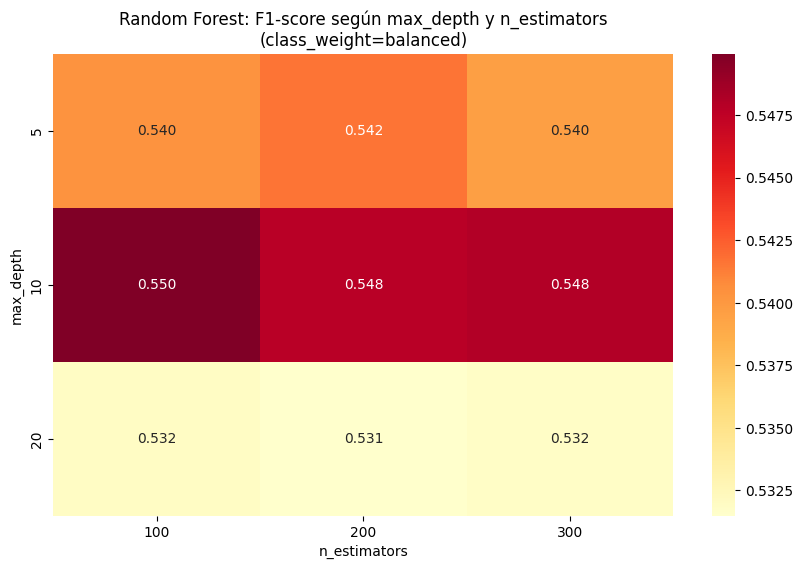

In [ ]:
# Random Forest: F1-score vs max_depth y n_estimators
results_rf = pd.DataFrame(grid_rf.cv_results_)
mask_rf = (results_rf['param_class_weight'] == 'balanced')
results_rf_filt = results_rf[mask_rf]

pivot_rf = results_rf_filt.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators',
    aggfunc='max'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_rf, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('Random Forest: F1-score según max_depth y n_estimators\n(class_weight=balanced)')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.show()

El siguiente mapa de calor muestra cómo varía el **F1-score** de Random
Forest según la profundidad máxima (`max_depth`) y el número de árboles
(`n_estimators`), manteniendo `class_weight='balanced'`. Los valores más
altos (tonos rojos) indican las mejores combinaciones.

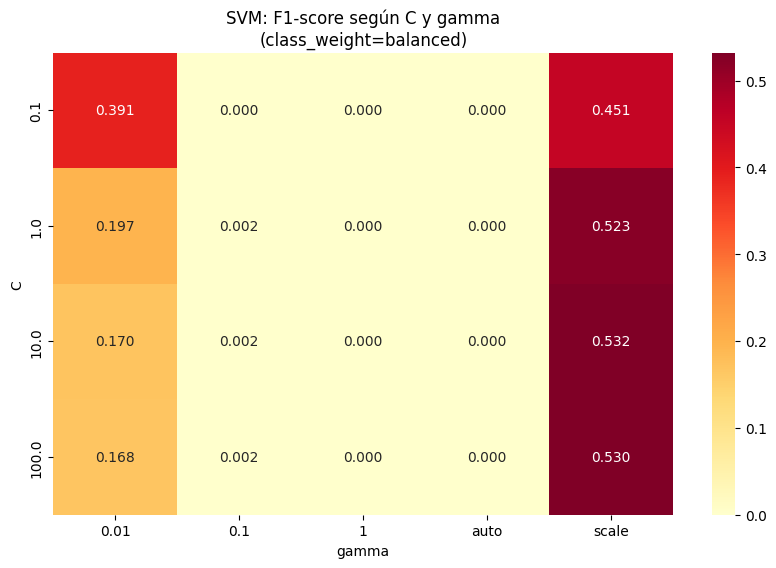

In [ ]:
# SVM: F1-score vs C y gamma
results_svm = pd.DataFrame(grid_svm.cv_results_)
mask_svm = results_svm['param_class_weight'] == 'balanced'
results_svm_filt = results_svm[mask_svm]

pivot_svm = results_svm_filt.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma',
    aggfunc='max'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_svm, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('SVM: F1-score según C y gamma\n(class_weight=balanced)')
plt.xlabel('gamma')
plt.ylabel('C')
plt.show()

El siguiente mapa de calor muestra cómo varía el **F1-score** de SVM
según el parámetro de regularización (`C`) y el coeficiente del kernel
(`gamma`), manteniendo `class_weight='balanced'`. Los valores más altos
(tonos rojos) indican las mejores combinaciones.

A continuación se presentan los mejores hiperparámetros encontrados para
cada modelo junto con su F1-score en validación cruzada. Estos modelos
optimizados serán evaluados en la **Sección 5** con las métricas finales
(F1-score y Balanced Accuracy) para seleccionar los más adecuados.

In [ ]:
print("\n" + "="*60)
print("RESUMEN: MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("="*60)

print(f"\nGaussianNB: configuración por defecto (sin hiperparámetros a ajustar)")
print(f"\nDecision Tree - Mejor F1: {grid_dt.best_score_:.4f}")
print(f"  Parámetros: {grid_dt.best_params_}")

print(f"\nRandom Forest - Mejor F1: {grid_rf.best_score_:.4f}")
print(f"  Parámetros: {grid_rf.best_params_}")

print(f"\nSVM - Mejor F1: {grid_svm.best_score_:.4f}")
print(f"  Parámetros: {grid_svm.best_params_}")


RESUMEN: MEJORES HIPERPARÁMETROS ENCONTRADOS

GaussianNB: configuración por defecto (sin hiperparámetros a ajustar)

Decision Tree - Mejor F1: 0.5095
  Parámetros: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}

Random Forest - Mejor F1: 0.5500
  Parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

SVM - Mejor F1: 0.5321
  Parámetros: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}


---
#**5. Resultados Generales y Visualización de los 4 Modelos**
---

El objetivo es comparar el rendimiento de los modelos base y preseleccionar los dos mejores para después hacer un estudio fino de hiperparámetros (Sección 5). Las matrices de confusión normalizadas nos permitirán inspeccionar los errores clase por clase.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (confusion_matrix, make_scorer, f1_score,
                             balanced_accuracy_score)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import numpy as np
import pandas as pd

# Preparar datos
X = df.drop('target', axis=1)
y = df['target']

# Modelos con mejores hiperparámetros encontrados
modelos = {
    'GaussianNB': GaussianNB(),

    'DecisionTree': DecisionTreeClassifier(
        random_state=21,
        max_depth=5,
        min_samples_leaf=2,
        min_samples_split=2,
        class_weight='balanced'
    ),

    'RandomForest': RandomForestClassifier(
        random_state=21,
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=4,
        min_samples_split=10,
        class_weight='balanced'
    ),

    'SVM': SVC(
        random_state=21,
        probability=True,
        C=10,
        gamma='scale',
        kernel='rbf',
        class_weight='balanced'
    )
}

# Métricas a evaluar
scorers = {
    'F1-score': make_scorer(f1_score),
    'Balanced Accuracy': make_scorer(balanced_accuracy_score)
}

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

print("Evaluando modelos optimizados...\n")

# Almacenar resultados
resultados = {}

for nombre, modelo in modelos.items():
    scores = {}
    for metrica, scorer in scorers.items():
        s = cross_val_score(modelo, X, y, cv=cv, scoring=scorer)
        scores[metrica] = (np.mean(s), np.std(s))
    resultados[nombre] = scores
    print(f"✓ {nombre} evaluado")

# Tabla comparativa
print("\n" + "="*60)
print("TABLA COMPARATIVA DE MODELOS OPTIMIZADOS")
print("="*60)

tabla = pd.DataFrame(index=resultados.keys(), columns=scorers.keys())
for nombre, scores in resultados.items():
    for metrica, (media, std) in scores.items():
        tabla.loc[nombre, metrica] = f"{media:.3f} ± {std:.3f}"

print(tabla)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de la tabla
modelos = ['GaussianNB', 'DecisionTree', 'RandomForest', 'SVM']

f1_means = [0.444, 0.510, 0.550, 0.532]
f1_stds  = [0.014, 0.012, 0.011, 0.003]

ba_means = [0.652, 0.731, 0.741, 0.744]
ba_stds  = [0.008, 0.011, 0.010, 0.004]

# Colores para destacar los mejores
colors_f1 = ['#87CEEB', '#87CEEB', '#FF6B6B', '#87CEEB']  # Rojo para el mejor F1
colors_ba = ['#87CEEB', '#87CEEB', '#87CEEB', '#4ECDC4']  # Verde para el mejor BalAcc

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica 1: F1-score ---
bars1 = ax1.bar(modelos, f1_means, yerr=f1_stds, color=colors_f1,
                edgecolor='black', capsize=8, alpha=0.8)
ax1.set_title('F1-score por Modelo', fontsize=14, fontweight='bold')
ax1.set_ylabel('F1-score')
ax1.set_ylim(0, 0.65)
ax1.grid(axis='y', alpha=0.3)

# Añadir etiquetas de valor sobre las barras
for bar, mean, std in zip(bars1, f1_means, f1_stds):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{mean:.3f}', ha='center', fontweight='bold')

# --- Gráfica 2: Balanced Accuracy ---
bars2 = ax2.bar(modelos, ba_means, yerr=ba_stds, color=colors_ba,
                edgecolor='black', capsize=8, alpha=0.8)
ax2.set_title('Balanced Accuracy por Modelo', fontsize=14, fontweight='bold')
ax2.set_ylabel('Balanced Accuracy')
ax2.set_ylim(0, 0.85)
ax2.grid(axis='y', alpha=0.3)

# Añadir etiquetas de valor sobre las barras
for bar, mean, std in zip(bars2, ba_means, ba_stds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{mean:.3f}', ha='center', fontweight='bold')

# Título general
fig.suptitle('Comparación de Modelos Optimizados', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, (nombre, modelo) in enumerate(modelos.items()):
    y_pred = cross_val_predict(modelo, X, y, cv=cv)
    cm = confusion_matrix(y, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['Benigno', 'Maligno'],
                yticklabels=['Benigno', 'Maligno'],
                ax=axes[idx])
    axes[idx].set_title(f'{nombre}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Real')
plt.suptitle('Matrices de Confusión Normalizadas - Modelos Optimizados', fontsize=16)
plt.tight_layout()
plt.show()

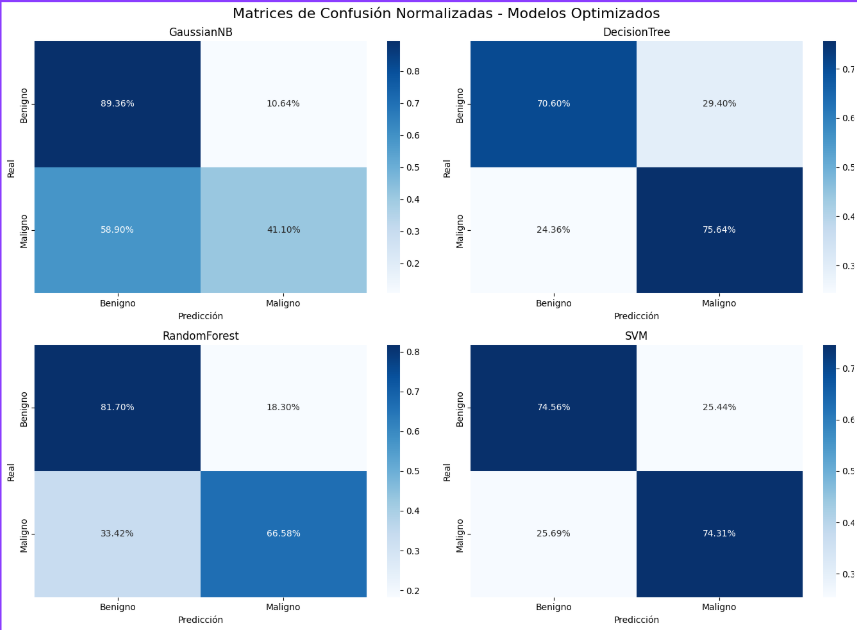

**Análisis de resultados:**

La tabla comparativa revela diferencias importantes entre los cuatro modelos
evaluados. **Random Forest** alcanzó el mejor F1-score (0.550 ± 0.011), lo
que indica que, de todos los modelos, es el que mejor equilibrio logra entre
precisión y sensibilidad. Esto significa que Random Forest no solo detecta
una proporción aceptable de lesiones malignas, sino que también mantiene
una tasa razonable de falsos positivos, evitando una avalancha de falsas
alarmas que saturaría innecesariamente el sistema de salud.

**SVM** obtuvo la mejor Balanced Accuracy (0.744 ± 0.004), superando
ligeramente a Random Forest (0.741 ± 0.010). La Balanced Accuracy es el
promedio simple de sensibilidad y especificidad, por lo que trata a las
clases benigna y maligna con igual importancia, sin verse afectada por el
fuerte desbalance del dataset (80.5% benignos, 19.5% malignos). Un valor
de 0.744 significa que, en promedio, el modelo acierta aproximadamente 3
de cada 4 casos en cada clase. Además, SVM mostró una estabilidad
excepcional, con una desviación estándar de solo ±0.003, lo que indica
que su rendimiento es prácticamente idéntico independientemente de cómo
se dividan los datos.

**DecisionTree** optimizado alcanzó un F1-score de 0.510 y una Balanced
Accuracy de 0.731, ubicándose en un punto intermedio. Si bien supera a
GaussianNB, se queda por detrás de Random Forest y SVM, posiblemente
debido a su tendencia al sobreajuste incluso con la profundidad limitada
a 5 niveles.

**GaussianNB**, al no disponer de hiperparámetros ajustables más allá de
`var_smoothing`, se mantuvo con su configuración por defecto y obtuvo el
rendimiento más bajo: F1-score de 0.444 y Balanced Accuracy de 0.652.
Este resultado refleja las limitaciones del modelo para capturar las
complejas relaciones entre las características extraídas de las imágenes
dermatoscópicas.

Es importante interpretar estos valores en el contexto clínico del
problema. Un F1-score de 0.550 o una Balanced Accuracy de 0.744, aunque
moderados, representan un avance significativo frente a una predicción
aleatoria (que tendría F1 ≈ 0.32 dado el desbalance). Sin embargo,
también evidencian que las características artesanales extraídas de las
imágenes (intensidad, textura, asimetría) tienen un poder discriminativo
limitado, y que la incorporación de características más sofisticadas o
el uso de redes neuronales convolucionales podrían mejorar sustancialmente
el rendimiento en futuras iteraciones.

---
#**6. Análisis Profundo y Patrones de Error**
---

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np
import random

# SVM final con mejores hiperparámetros
svm_final = SVC(
    random_state=21,
    probability=True,
    C=10,
    gamma='scale',
    kernel='rbf',
    class_weight='balanced'
)

# Predicciones usando validación cruzada
y_pred_svm = cross_val_predict(svm_final, X, y, cv=cv)

# Encontrar errores
errores = np.where(y != y_pred_svm)[0]

print("Cantidad de errores:", len(errores))

# Separar tipos de error
benigno_a_maligno = [
    idx for idx in errores
    if y.iloc[idx] == 0 and y_pred_svm[idx] == 1
]

maligno_a_benigno = [
    idx for idx in errores
    if y.iloc[idx] == 1 and y_pred_svm[idx] == 0
]

# Elegir ejemplos aleatorios
ejemplos_bm = random.sample(
    benigno_a_maligno,
    min(2, len(benigno_a_maligno))
)

ejemplos_mb = random.sample(
    maligno_a_benigno,
    min(2, len(maligno_a_benigno))
)

# Mostrar ejemplos
fig, axes = plt.subplots(2, 2, figsize=(6,6))

# Benigno -> Maligno
for i, idx in enumerate(ejemplos_bm):

    img = row_to_img_auto(ham28_rgb.iloc[idx])

    axes[0, i].imshow(img)
    axes[0, i].set_title("Benigno → Maligno")
    axes[0, i].axis('off')

# Maligno -> Benigno
for i, idx in enumerate(ejemplos_mb):

    img = row_to_img_auto(ham28_rgb.iloc[idx])

    axes[1, i].imshow(img)
    axes[1, i].set_title("Maligno → Benigno")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Encontrar índices correctamente clasificados
correctos = np.where(y == y_pred_svm)[0]

# Separar benignos y malignos correctos
benignos_correctos = [idx for idx in correctos if y.iloc[idx] == 0]
malignos_correctos = [idx for idx in correctos if y.iloc[idx] == 1]

# Mostrar ejemplos
fig, axes = plt.subplots(2, 2, figsize=(6,6))

# Benignos correctamente clasificados
for i, idx in enumerate(benignos_correctos[:2]):

    img = row_to_img_auto(ham28_rgb.iloc[idx])

    axes[0, i].imshow(img)
    axes[0, i].set_title("Benigno → Benigno")
    axes[0, i].axis('off')

# Malignos correctamente clasificados
for i, idx in enumerate(malignos_correctos[:2]):

    img = row_to_img_auto(ham28_rgb.iloc[idx])

    axes[1, i].imshow(img)
    axes[1, i].set_title("Maligno → Maligno")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Índices correctos y errores
correctos = np.where(y == y_pred_svm)[0]
errores = np.where(y != y_pred_svm)[0]

# DataFrames separados
df_correctos = df.iloc[correctos]
df_errores = df.iloc[errores]

# Comparar medias
comparacion = pd.DataFrame({
    'Correctos': df_correctos.mean(),
    'Errores': df_errores.mean()
})

# Diferencia absoluta
comparacion['Diferencia'] = abs(
    comparacion['Correctos'] - comparacion['Errores']
)

# Ordenar por diferencia
comparacion = comparacion.sort_values(
    by='Diferencia',
    ascending=False
)

print(comparacion)

---
#**7. Conclusiones**
---

Conclusiones:
- El SVM obtuvo el mejor rendimiento general con una balanced accuracy del 74.4%.
- Las features de textura y forma permitieron distinguir gran parte de las lesiones benignas y malignas.
- La resolución 28x28 y las features manuales limitaron la capacidad de clasificación en casos ambiguos.

Perspectivas a futuro:
- Reentrenar los modelos utilizando imágenes de mayor resolución para conservar más detalle visual.
- Implementar métodos de segmentación más precisos para mejorar features como área y asimetría.
- Explorar nuevas features de textura y color para representar mejor lesiones visualmente ambiguas.